## Project - part 2.2

Для анализа был выбран датасет Bank Marketing (данные португальского банка)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

bank = pd.read_csv("bank-additional-full.csv", sep=';')

In [ ]:
bank

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes


In [ ]:
for i in bank.columns:
    print(bank[f'{i}'].value_counts())

age
31    1947
32    1846
33    1833
36    1780
35    1759
      ... 
91       2
98       2
95       1
87       1
94       1
Name: count, Length: 78, dtype: int64
job
admin.           10422
blue-collar       9254
technician        6743
services          3969
management        2924
retired           1720
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
student            875
unknown            330
Name: count, dtype: int64
marital
married     24928
single      11568
divorced     4612
unknown        80
Name: count, dtype: int64
education
university.degree      12168
high.school             9515
basic.9y                6045
professional.course     5243
basic.4y                4176
basic.6y                2292
unknown                 1731
illiterate                18
Name: count, dtype: int64
default
no         32588
unknown     8597
yes            3
Name: count, dtype: int64
housing
yes        21576
no         18622
unknown      990
Name: count, 

In [ ]:
bank[(bank['default'] == 'unknown') & (bank['loan'] == 'no') & (bank['housing'] == 'no')]

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
5,45,services,married,basic.9y,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
7,41,blue-collar,married,unknown,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
10,41,blue-collar,married,unknown,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
19,39,management,single,basic.9y,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40673,45,unemployed,married,professional.course,unknown,no,no,cellular,sep,thu,...,1,999,0,nonexistent,-1.1,94.199,-37.5,0.879,4963.6,yes
40702,82,retired,married,university.degree,unknown,no,no,cellular,sep,mon,...,3,3,4,success,-1.1,94.199,-37.5,0.879,4963.6,no
40714,84,retired,divorced,unknown,unknown,no,no,cellular,sep,tue,...,1,3,2,success,-1.1,94.199,-37.5,0.877,4963.6,yes
40886,70,retired,married,basic.4y,unknown,no,no,cellular,oct,thu,...,1,14,3,failure,-1.1,94.601,-49.5,0.965,4963.6,no


In [ ]:
mask = (bank['default'] == 'unknown') & (bank['loan'] == 'no') & (bank['housing'] == 'no')
bank.loc[mask, 'default'] = 'no'

In [ ]:
bank[bank['default'] == 'unknown']

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
15,54,retired,married,basic.9y,unknown,yes,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
17,46,blue-collar,married,basic.6y,unknown,yes,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
21,55,blue-collar,married,basic.4y,unknown,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
29,55,unknown,married,university.degree,unknown,unknown,unknown,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
33,54,management,married,basic.4y,unknown,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40718,86,retired,married,unknown,unknown,yes,yes,cellular,sep,tue,...,1,7,4,success,-1.1,94.199,-37.5,0.877,4963.6,yes
40727,86,retired,married,unknown,unknown,yes,no,cellular,sep,tue,...,1,999,0,nonexistent,-1.1,94.199,-37.5,0.877,4963.6,yes
40941,66,retired,married,basic.4y,unknown,unknown,unknown,cellular,oct,wed,...,1,6,3,success,-1.1,94.601,-49.5,0.985,4963.6,yes
40969,84,retired,divorced,basic.4y,unknown,yes,no,cellular,oct,fri,...,4,999,0,nonexistent,-1.1,94.601,-49.5,0.993,4963.6,no


In [ ]:
bank

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes


In [ ]:
bank[(bank['default'] == 'unknown') & (bank['loan'] == 'no') & (bank['housing'] == 'no')]

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y


In [ ]:
bank

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes


In [ ]:
bank.dtypes

,0
age,int64
job,object
marital,object
education,object
default,object
housing,object
loan,object
contact,object
month,object
day_of_week,object


In [ ]:
#Разделение на числовые и категориальные колонки
num_cols = bank.select_dtypes(include=np.number).columns.tolist()
cat_cols = bank.select_dtypes(exclude=np.number).columns.tolist()

In [ ]:
# Уберём целевую переменную из категориальных, если она там
if 'y' in cat_cols:
    cat_cols = [c for c in cat_cols if c != 'y']

In [ ]:
bank.isna().count()

,0
age,41188
job,41188
marital,41188
education,41188
default,41188
housing,41188
loan,41188
contact,41188
month,41188
day_of_week,41188


<Axes: xlabel='age', ylabel='Count'>

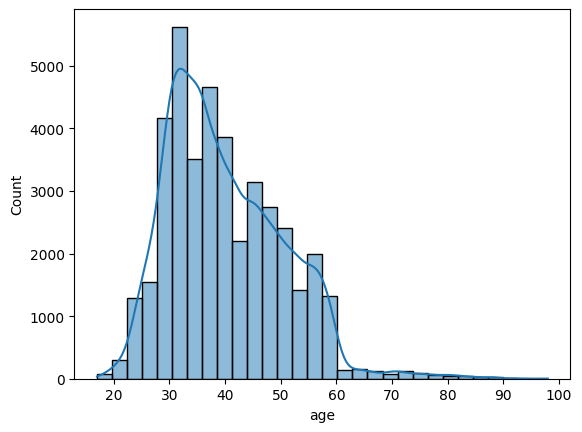

In [ ]:
sns.histplot(bank['age'], kde=True, bins=30)

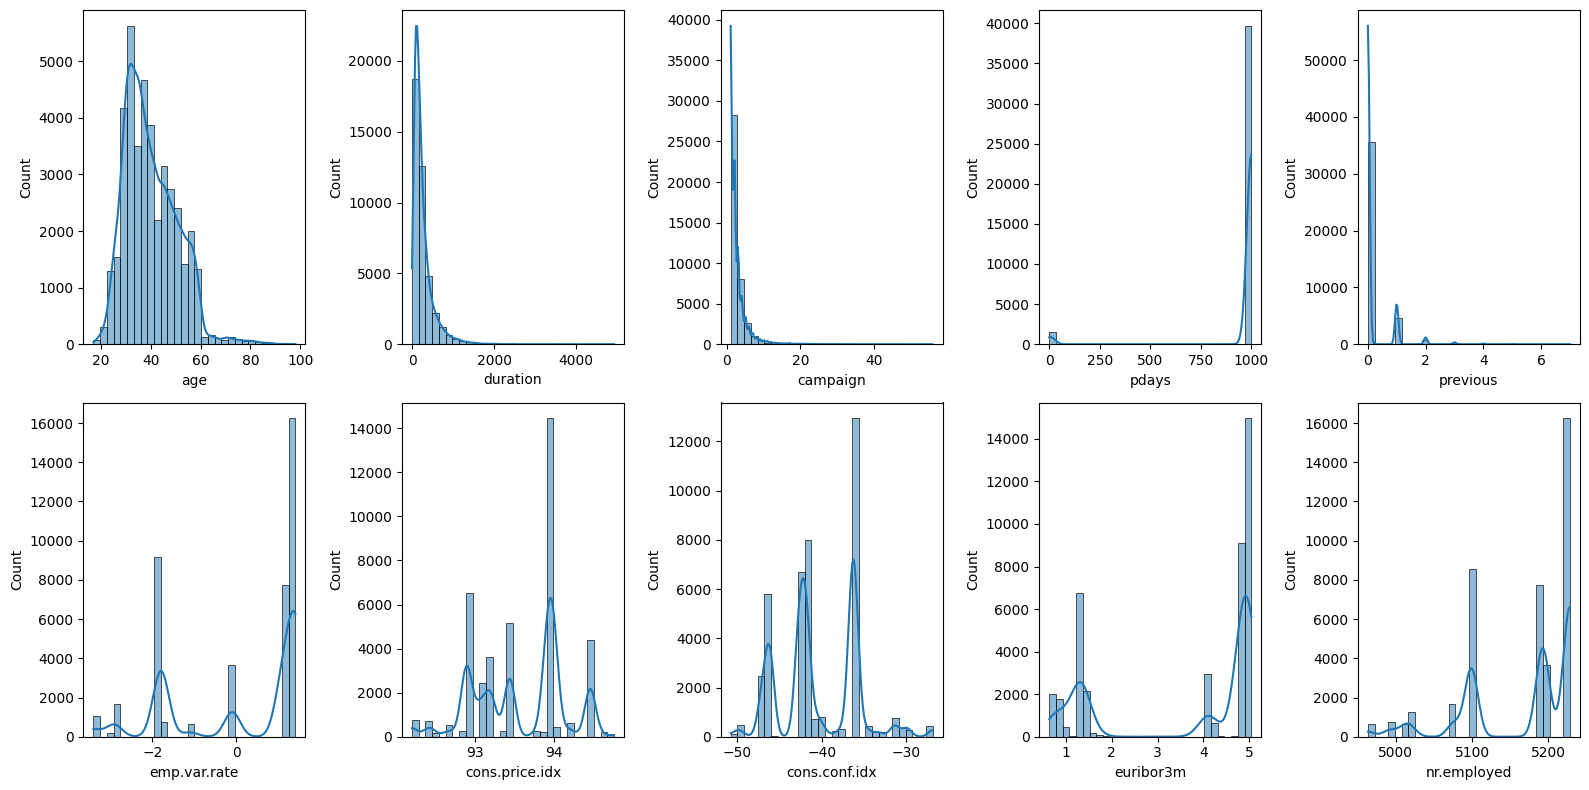

In [ ]:
#Распределения числовых признаков
n = len(num_cols)
n_cols_plot = 5
n_rows = (n + n_cols_plot - 1) // n_cols_plot

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols_plot, figsize=(16, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(bank[col].dropna(), kde=True, ax=axes[i], bins=30)
    # axes[i].set_title(col)

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()

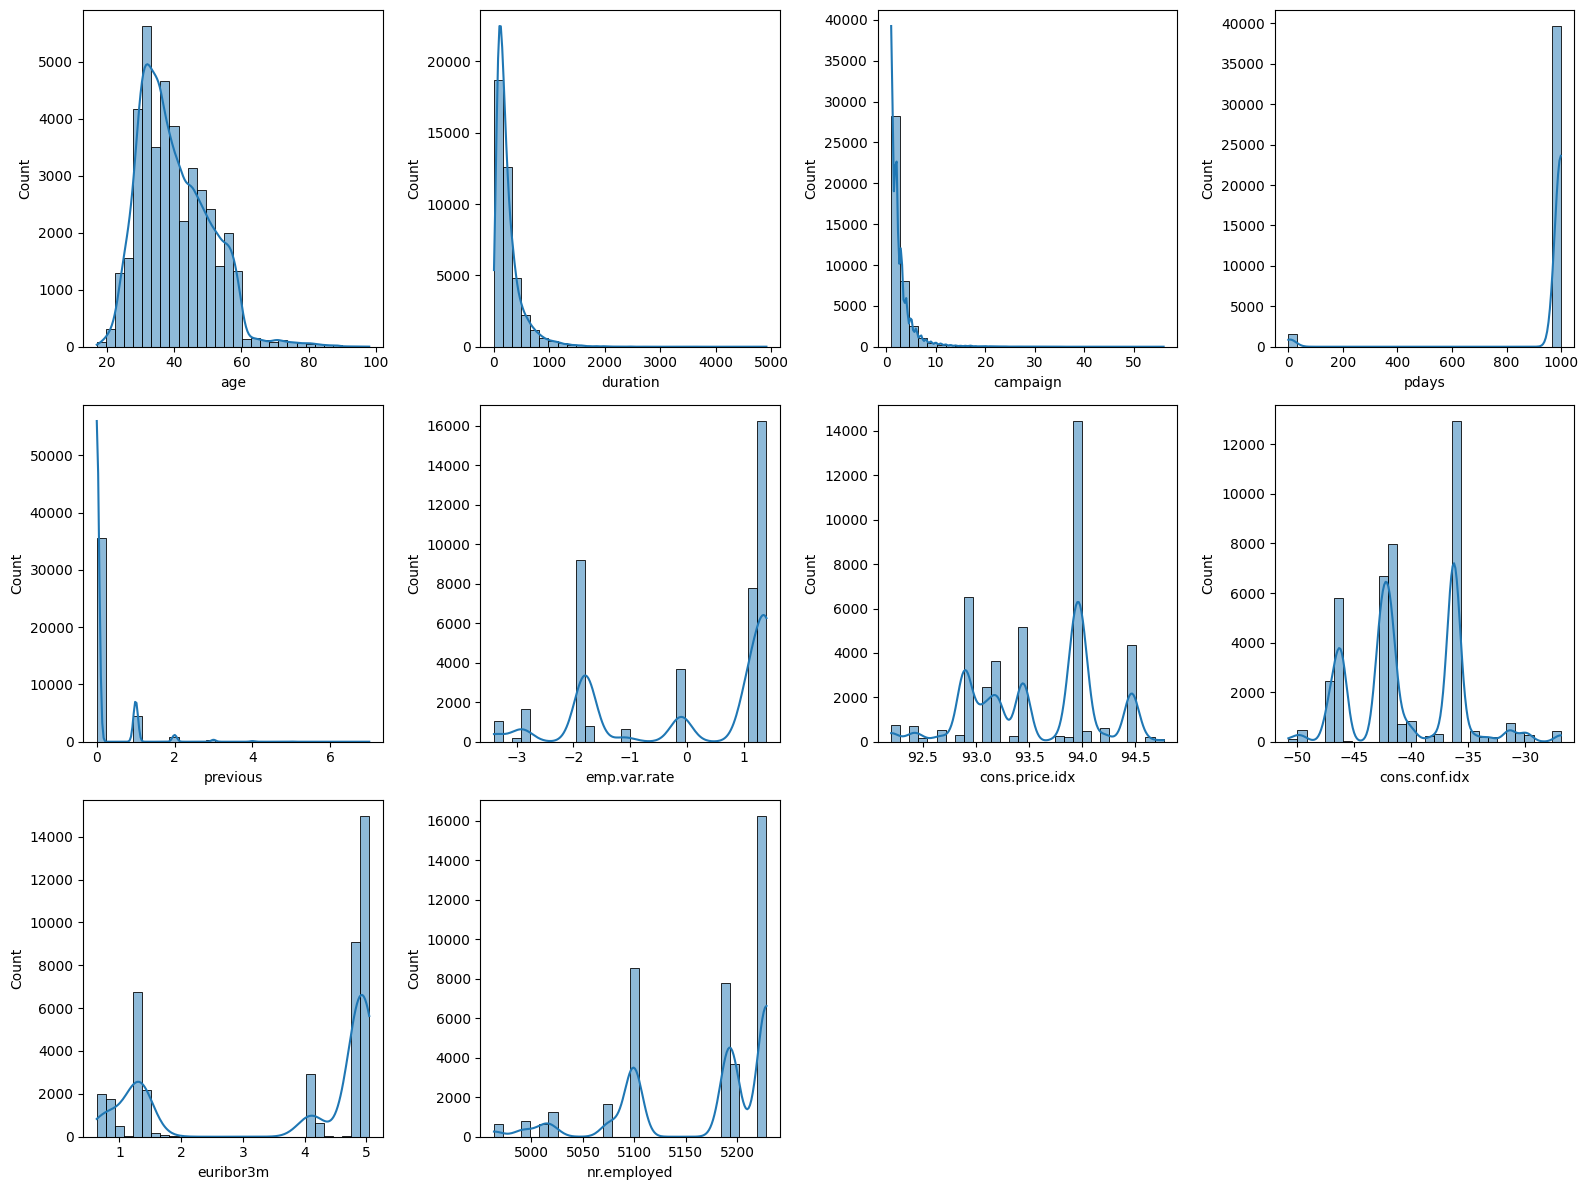

In [ ]:
# === 6. Визуализация: распределения числовых признаков ===
n = len(num_cols)
n_cols_plot = 4
n_rows = (n + n_cols_plot - 1) // n_cols_plot

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols_plot, figsize=(16, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(bank[col].dropna(), kde=True, ax=axes[i], bins=30)
    # axes[i].set_title(col)

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()

In [ ]:
bank

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes


Text(0.5, 1.0, 'Распределение целевой переменной')

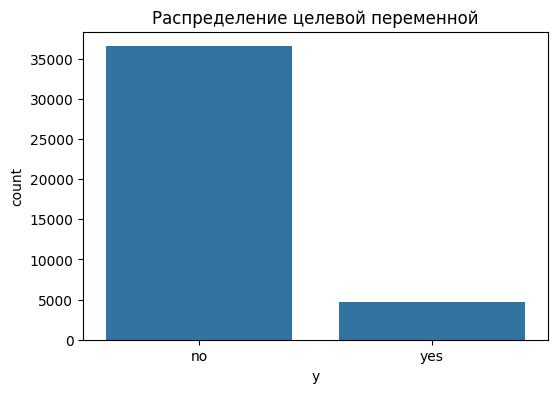

In [ ]:
#Распределение целевой переменной
plt.figure(figsize=(6, 4))
sns.countplot(data=bank, x='y')
plt.title('Распределение целевой переменной')

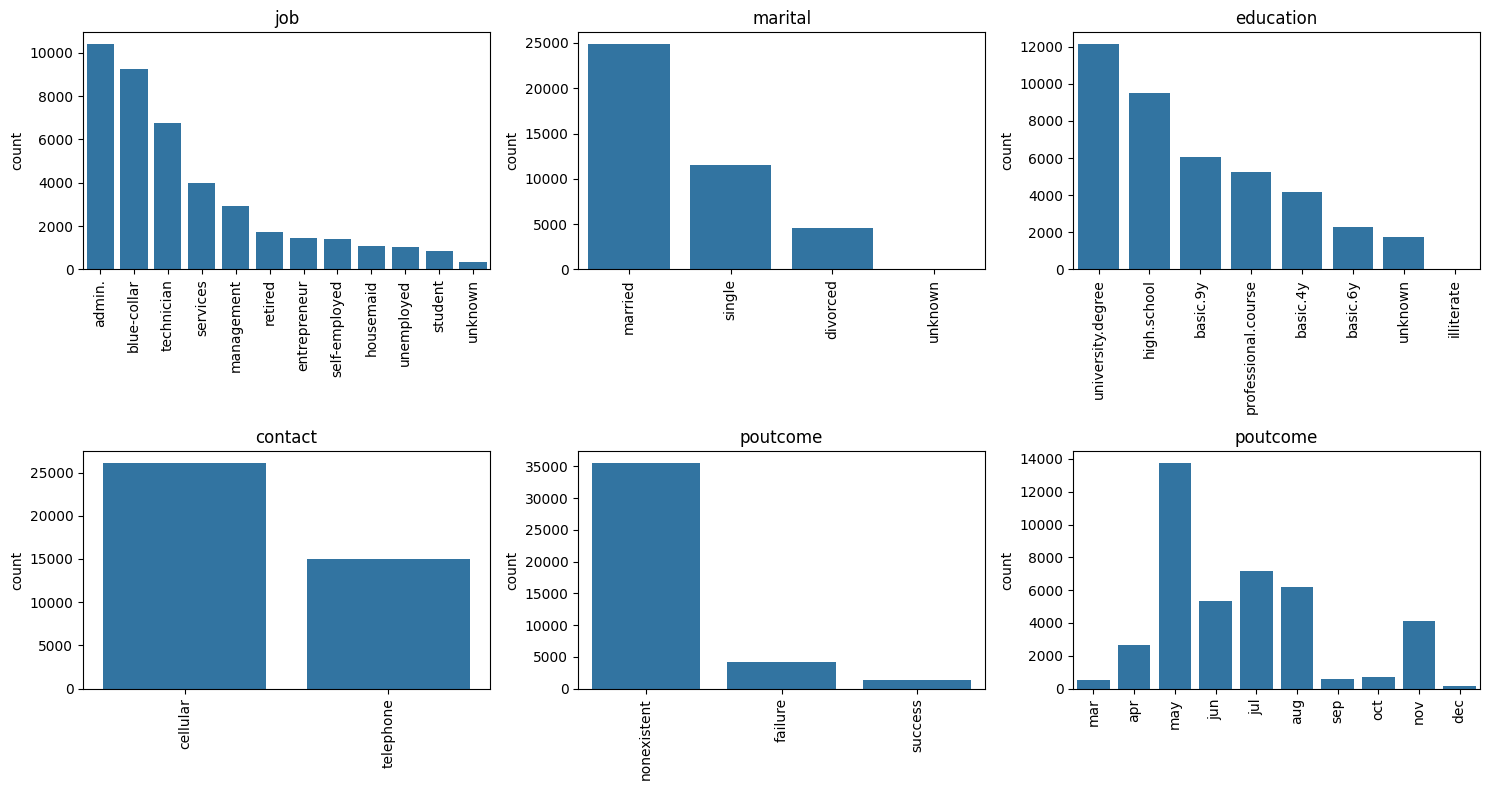

In [ ]:
# Визуализируем категориальные признаки
cat_to_plot = ['job', 'marital', 'education', 'contact' , 'poutcome']

n = len(cat_to_plot)
n_cols_plot = 3
n_rows = (n + n_cols_plot - 1) // n_cols_plot

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols_plot, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cat_to_plot):
    if col in bank.columns:
        order = bank[col].value_counts().index
        sns.countplot(data=bank, x=col, ax=axes[i], order=order)
        axes[i].tick_params(axis='x', rotation=90)
        axes[i].set_title(col)
        axes[i].set_xlabel('')

# помещаем распределение по месяцам в порядке расположения месяцев в году
sns.countplot(data=bank, x='month', ax=axes[5], order=['mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec'])
axes[5].tick_params(axis='x', rotation=90)
axes[5].set_title(col)
axes[5].set_xlabel('')

for j in range(6, len(axes)):
    axes[j].axis('off')

plt.tight_layout()

In [ ]:
# num_cols for boxplots:
num_cols = ['age', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

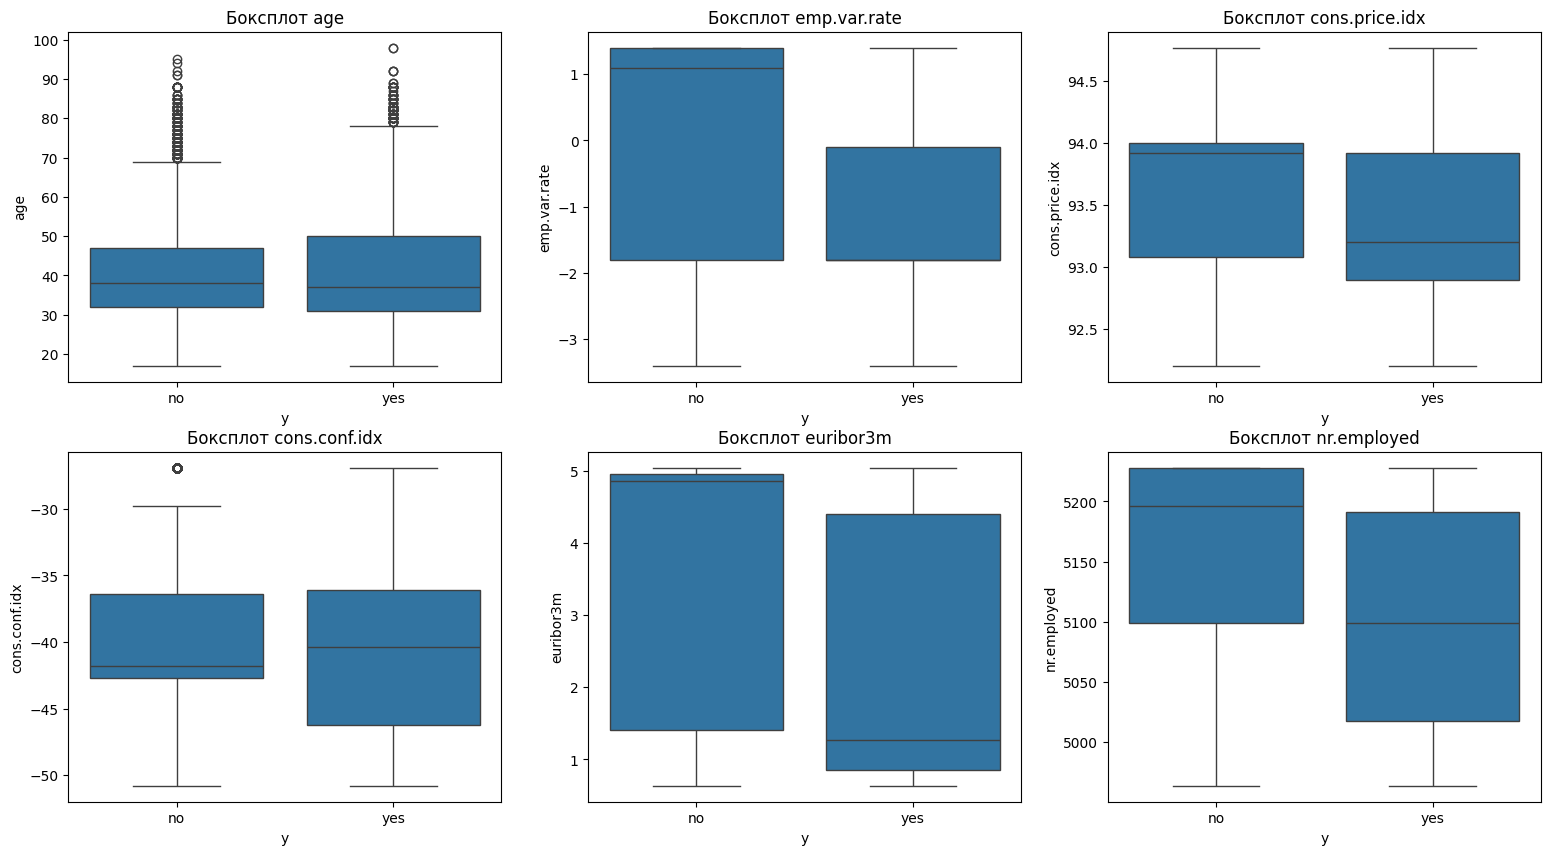

In [ ]:
plt.figure(figsize=(19,10))

for i in range(6):
    plt.subplot(2, 3, i+1)
    sns.boxplot(data=bank, y=num_cols[i], x='y')
    plt.title(f'Боксплот {num_cols[i]}')

In [ ]:
# num_cols for boxplots:
num_cols = ['duration', 'campaign', 'pdays', 'previous']

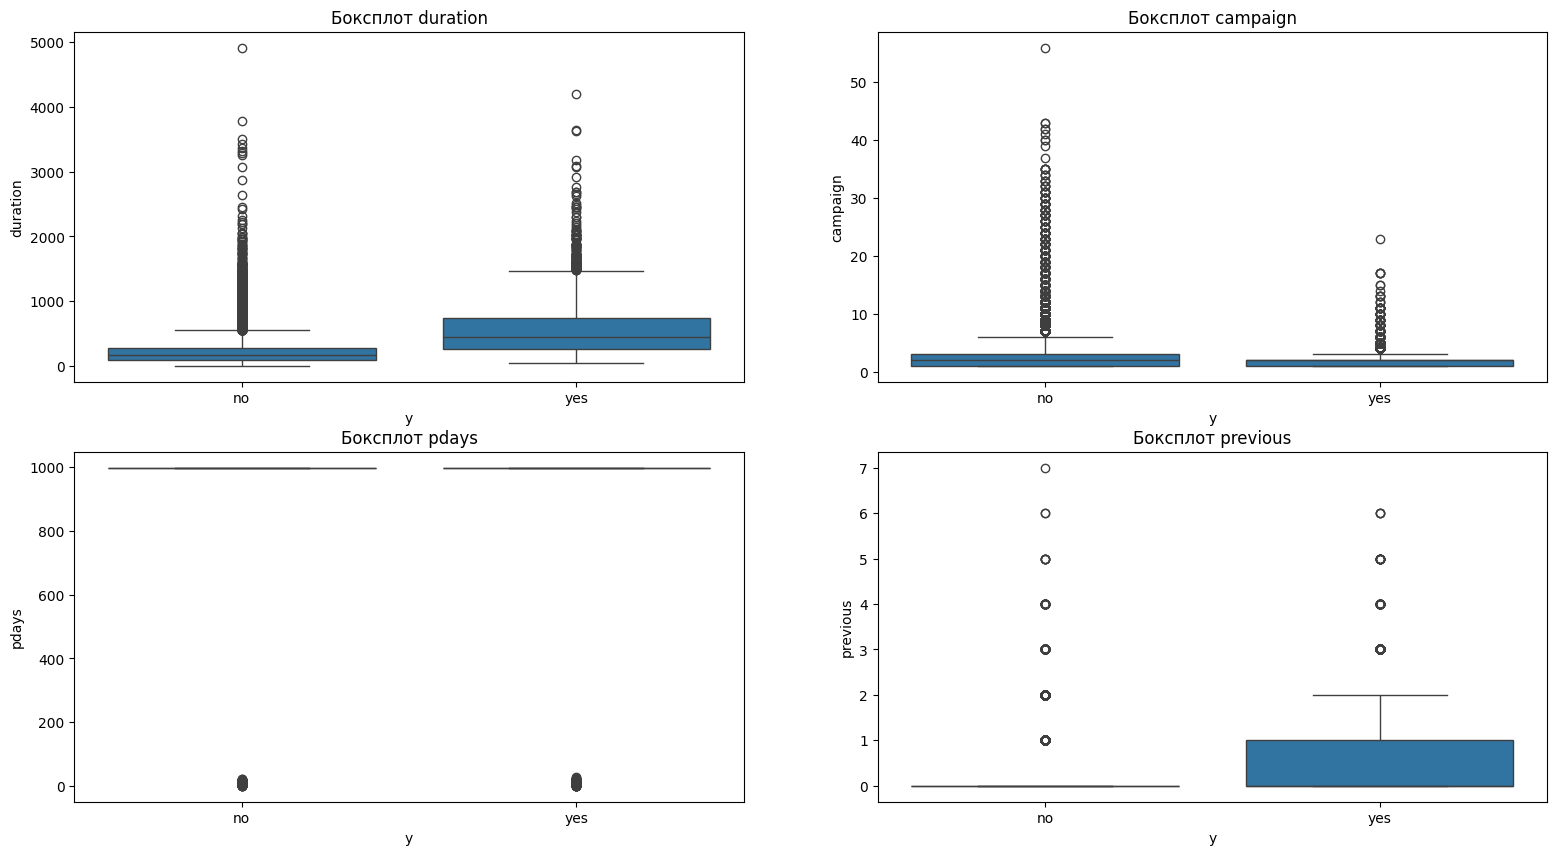

In [ ]:
plt.figure(figsize=(19,10))

for i in range(4):
    plt.subplot(2, 2, i+1)
    sns.boxplot(data=bank, y=num_cols[i], x='y')
    plt.title(f'Боксплот {num_cols[i]}')

<Axes: xlabel='y', ylabel='duration'>

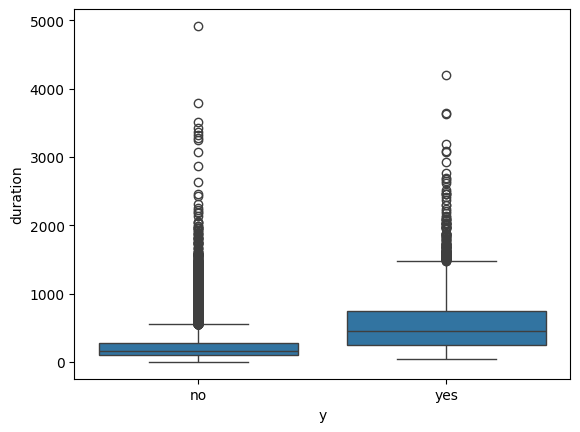

In [ ]:
sns.boxplot(data=bank, y='duration', x='y')

In [ ]:
bank_log = bank.copy()
bank_log['campaign'] = np.log(bank['campaign'])

<Axes: xlabel='y', ylabel='campaign'>

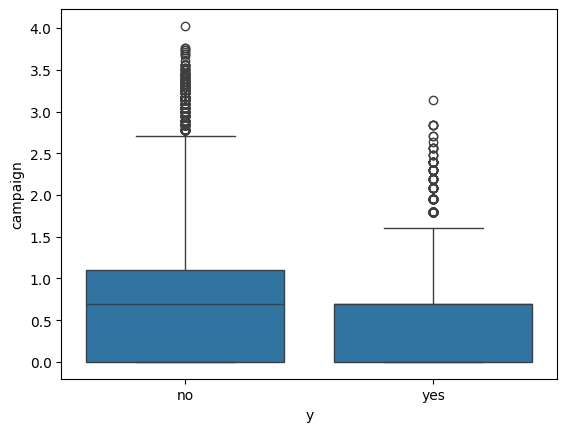

In [ ]:
sns.boxplot(data=bank_log, y='campaign', x='y')

In [ ]:
bank_log = bank.copy()
bank_log['previous'] = np.log(bank['previous'])

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


<Axes: xlabel='y', ylabel='previous'>

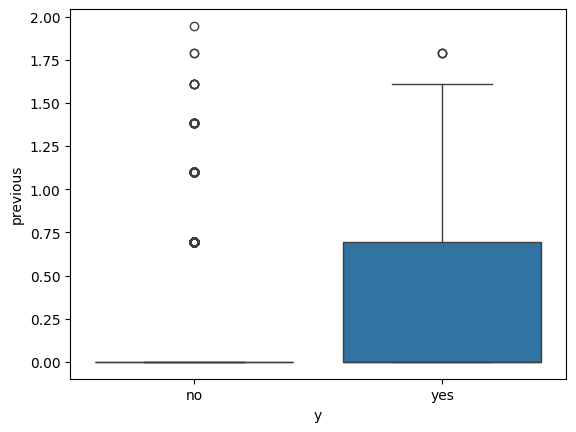

In [ ]:
sns.boxplot(data=bank_log, y='previous', x='y')

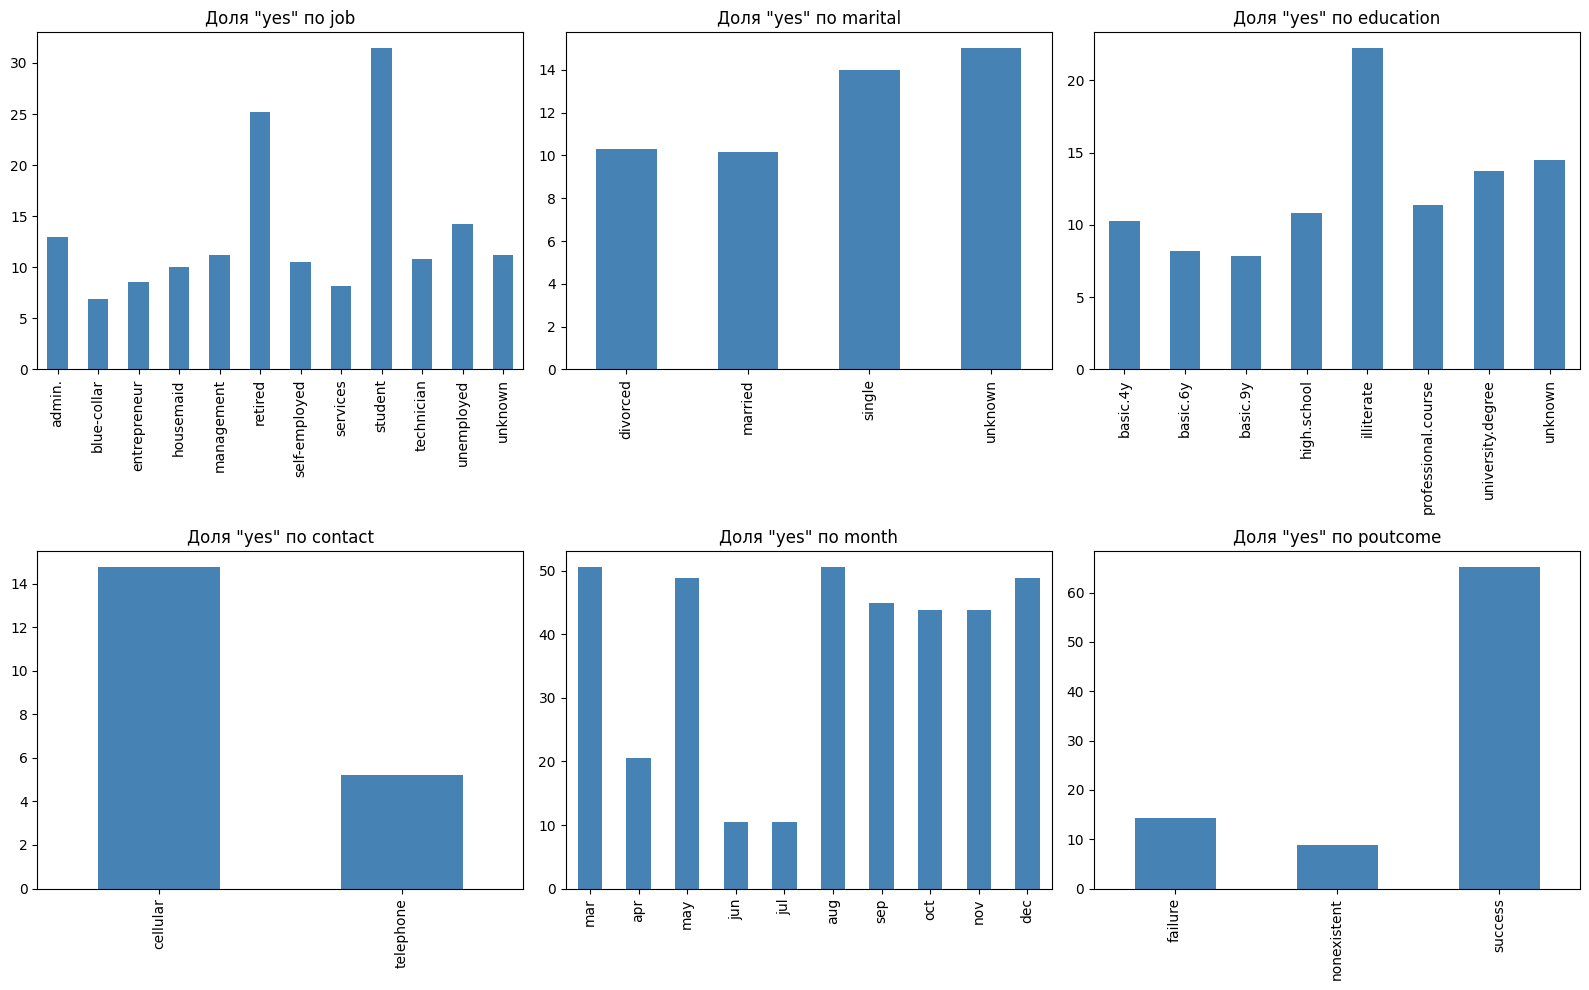

In [ ]:
#Доля yes по категориям
cat_for_target = ['job', 'marital', 'education', 'contact', 'month', 'poutcome']

n = len(cat_for_target)
n_cols_plot = 3
n_rows = (n + n_cols_plot - 1) // n_cols_plot

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols_plot, figsize=(16, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cat_for_target):
    if col in bank.columns:
        # Доля yes по каждой категории
        cross_tab = pd.crosstab(bank[col], bank['y'], normalize='index') * 100
        cross_tab['yes'].plot(kind='bar', ax=axes[i], color='steelblue')
        axes[i].set_title(f'Доля "yes" по {col}')
        axes[i].tick_params(axis='x', rotation=90)
        axes[i].set_xlabel('')

if 'month' in bank.columns:
    month_order = ['mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']
    existing_months = [m for m in month_order if m in bank['month'].unique()]

    cross_tab_month = pd.crosstab(bank['month'], bank['y'], normalize='index').loc[existing_months] * 100
    cross_tab_month['yes'].plot(kind='bar', ax=axes[cat_for_target.index('month')], color='steelblue')
    axes[cat_for_target.index('month')].set_title('Доля "yes" по month')
    axes[cat_for_target.index('month')].tick_params(axis='x', rotation=90)
    axes[cat_for_target.index('month')].set_xlabel('')

for j in range(len(cat_for_target), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

### 1 ГИПОТЕЗА

In [ ]:
duration_yes = bank[bank['y'] == 'yes']['duration'].dropna()
duration_no = bank[bank['y'] == 'no']['duration'].dropna()

In [ ]:
from scipy.stats import kstest
import numpy as np

# Для группы yes
duration_yes_std = (duration_yes - np.mean(duration_yes)) / np.std(duration_yes)
ks_yes = kstest(duration_yes_std, 'norm')
print(f"K-S test для 'yes': p = {ks_yes.pvalue:.2e}")

K-S test для 'yes': p = 2.35e-54


Результат: p < 0.001 для обеих групп → распределение НЕ нормальное

In [ ]:
# Для группы 'no'
duration_no_std = (duration_no - np.mean(duration_no)) / np.std(duration_no)
ks_no = kstest(duration_no_std, 'norm')
print(f"K-S test для 'no': p = {ks_no.pvalue:.2e}")

K-S test для 'no': p = 0.00e+00


Text(0.5, 1.0, 'Q-Q Plot для проверки нормальности для группы А')

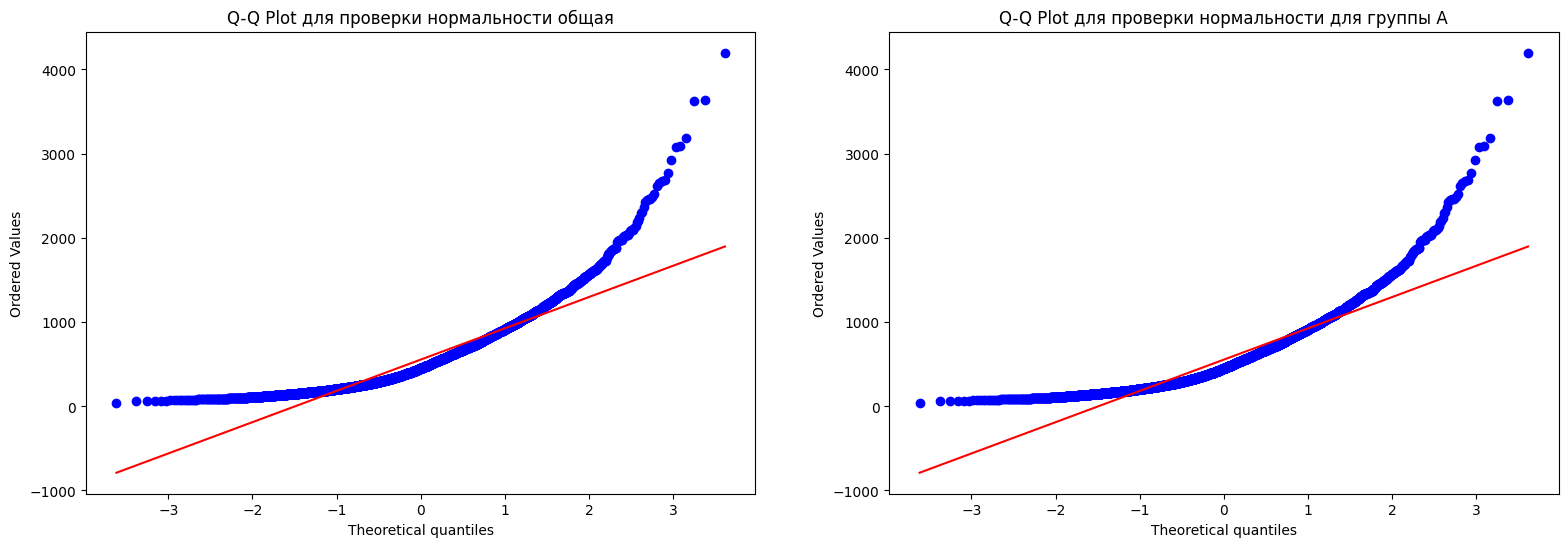

In [ ]:
from scipy import stats as st

plt.figure(figsize=(19, 6))
plt.subplot(1, 2, 1)
st.probplot(duration_yes, dist="norm", plot=plt)
plt.title('Q-Q Plot для проверки нормальности общая')

plt.subplot(1, 2, 2)
st.probplot(duration_yes, dist="norm", plot=plt)
plt.title('Q-Q Plot для проверки нормальности для группы А')

In [ ]:
from scipy.stats import mannwhitneyu

# Проверка Гипотезы 1: влияет ли duration на y?
# Альтернатива: медиана duration у 'yes' больше, чем у 'no'
mannwhitneyu(duration_yes, duration_no, alternative='greater')

MannwhitneyuResult(statistic=np.float64(138794276.5), pvalue=np.float64(0.0))

# **ОБОСНОВАНИЕ:**

## **Гипотеза:**
"Длительность звонка (duration) у клиентов, согласившихся на депозит (y='yes'), больше, чем у отказавшихся (y='no')"

Перед сравнением двух групп по числовому признаку нужно выбрать тест:
- **t-тест** → требует нормального распределения
- **Mann-Whitney U** → не требует нормальности

Сначала проверяем нормальность, потом выбираем тест.

## Обоснование выбора теста на нормальность**

### **A) Q-Q plot (графический метод)**
**Что видим на графике:**
- Точки сильно отклоняются от прямой
- Правосторонняя асимметрия (длинный правый хвост)
- **Вывод:** Распределение явно не нормальное

### **B) Тест Колмогорова-Смирнова (K-S test)**

**Обоснование выбора:**
1. **Для больших выборок** (у нас > 40,000 наблюдений)
   - Тест Шапиро-Уилка работает только до ~5,000 наблюдений
   - K-S test подходит для любых объёмов
   
2. **Проверяет конкретную гипотезу:**
   - H₀: Распределение соответствует нормальному
   - H₁: Распределение не соответствует нормальному

3. **Результат:**
   p < 0.001 → отвергаем H₀ → распределение НЕ нормальное

## Обоснование выбора Mann-Whitney U test

### **Почему НЕ t-тест:**
1. Нарушено предположение о нормальности (K-S test: p < 0.001)
2. Наличие выбросов
3. Правосторонняя асимметрия — распределение скошено вправо

## **Mann-Whitney U:**
1. Не требует предположения о нормальности
2. Устойчив к выбросам
3. Независимые группы (Клиенты 'yes' и 'no' — разные люди)
4. Проверяет сдвиг медиан (именно наша гипотеза: "медиана yes > медиана no")

## Альтернативы, которые мы отвергли:

1. t-тест Стьюдента -> Требует нормальности (нарушено)
2. Тест Уэлча (Welch's t-test) -> разрешает неравные дисперсии, но всё равно требует приблизительной нормальности
3. Bootstrap-тест -> Требует больше вычислений. Mann-Whitney — стандартный выбор для таких задач



##**Итоговая интерпретация и выводы**
**Гипотеза 1: Длительность звонка (duration) влияет на подписку (y)**

    Результат: p-value ≈ 0 → гипотеза подтверждена.
    Статистика: Клиенты, подписавшие депозит (y="yes"), в среднем разговаривали в 2 раза дольше, чем те, кто отказался.
    Интерпретация:
    Это может означать:
        Качественные звонки (с активным вовлечением, чётким объяснением продукта) занимают больше времени,
        Клиенты, заинтересованные в продукте, задают больше вопросов и дольше обсуждают детали.
    Бизнес-рекомендации:
        Использовать duration как proxy-метрику качества звонка в колл-центре.
        Обучать операторов вести более содержательные и продолжительные беседы с потенциальными клиентами (но не искусственно затягивать!).
        Оптимизировать скрипты диалога: если первые 1–2 минуты не вызывают интереса — пересматривать подход.

### 2 ГИПОТЕЗА

In [ ]:
from scipy.stats import chi2_contingency

# Проверка Гипотезы 2: связаны ли job и y?
contingency_table = pd.crosstab(bank['job'], bank['y'])

chi2_contingency(contingency_table)

Chi2ContingencyResult(statistic=np.float64(961.2424403289555), pvalue=np.float64(4.189763287563623e-199), dof=11, expected_freq=array([[9247.91822861, 1174.08177139],
       [8211.49830048, 1042.50169952],
       [1291.97552685,  164.02447315],
       [ 940.58657862,  119.41342138],
       [2594.59920365,  329.40079635],
       [1526.23482568,  193.76517432],
       [1260.91842284,  160.08157716],
       [3521.87559483,  447.12440517],
       [ 776.42760027,   98.57239973],
       [5983.37292415,  759.62707585],
       [ 899.76867049,  114.23132951],
       [ 292.82412353,   37.17587647]]))

In [ ]:
# Считаем конверсию по профессиям
conversion_by_job = contingency_table['yes'] / contingency_table.sum(axis=1)

print("ЛУЧШИЕ профессии по конверсии:")
print(conversion_by_job.sort_values(ascending=False).head(3))

print("\nХУДШИЕ профессии по конверсии:")
print(conversion_by_job.sort_values().head(3))

ЛУЧШИЕ профессии по конверсии:
job
student       0.314286
retired       0.252326
unemployed    0.142012
dtype: float64

ХУДШИЕ профессии по конверсии:
job
blue-collar     0.068943
services        0.081381
entrepreneur    0.085165
dtype: float64


**Гипотеза 2: Профессия (job) влияет на вероятность подписки**

    Результат: p-value ≈ 0 → гипотеза подтверждена.
    Наблюдения:
        Наибольшая доля yes: студенты, управленцы, техники.
        Наименьшая доля: домохозяйки, пенсионеры, рабочие.
    Интерпретация:
    Разные профессиональные группы имеют разные финансовые цели, уровень образования и доверие к банку. Например:
        Студенты — более открыты к новым финансовым инструментам,
        Управленцы — имеют стабильный доход и интересуются накоплениями.
    Бизнес-рекомендации:
        Сегментировать клиентов по профессиональной принадлежности,
        Фокусировать маркетинг на «высокодоходных» сегментах (student, management, technician),
        Разрабатывать персонализированные предложения для каждой группы (например, для студентов — накопительные счета с бонусами).

**ОБОСНОВАНИЕ ВЫБОРА χ²-TEST ДЛЯ ПРОВЕРКИ СВЯЗИ JOB И Y**:

1. ТИП ДАННЫХ:
   * Независимая переменная: job (категориальная, 11 уровней)
   * Зависимая переменная: y (категориальная, бинарная)
   * Анализ: проверка связи двух категориальных переменных

2. ПРЕДПОСЫЛКИ χ²-TEST:
   * Независимость наблюдений (каждый клиент независим)
   * Ожидаемые частоты > 5 (min=98.6 > 5)
   * Категориальные данные (обе переменные категориальные)
   * Случайная выборка (предполагаем)

3. ВЫБОР ТЕСТА:
   * χ²-test для таблицы сопряженности — стандартный метод
   * Проверяет: "Распределение y одинаково для всех job?"
   * Альтернатива H₁: "Хотя бы для одного job распределение другое"

4. АЛЬТЕРНАТИВЫ ОТВЕРГНУТЫ:
   * z-тесты попарно → проблема множественных сравнений
   * Логистическая регрессия → overkill для этой задачи
   * Тест Фишера → только для таблиц 2×2
   * G-тест → менее распространён, результаты похожи

5. РЕЗУЛЬТАТ И ИНТЕРПРЕТАЦИЯ:
   * χ² = 961.2, df = 10, p ≈ 4e-200 → связь ОЧЕНЬ значима
   * Коэффициент Крамера V ≈ 0.15 → умеренная сила связи
   * Вывод: Профессия статистически значимо влияет на конверсию

### 3 ГИПОТЕЗА

In [ ]:
#Переводим y в числовой формат
df['y_num'] = df['y'].map({'no': 0, 'yes': 1})
df_clean = df.dropna(subset=['poutcome', 'y_num'])

df_clean['poutcome'] = df_clean['poutcome'].astype(str).str.strip()
poutcome_dummies = pd.get_dummies(df_clean['poutcome'], prefix='poutcome')

if 'poutcome_nonexistent' in poutcome_dummies.columns:
    poutcome_dummies = poutcome_dummies.drop(columns=['poutcome_nonexistent'])

X = poutcome_dummies
y = df_clean['y_num']

#Конвертируем в float, чтобы избежать ошибки в statsmodels
X = X.astype(float)
y = y.astype(float)

X = sm.add_constant(X)

model = sm.Logit(y, X).fit(disp=False)

print(model.summary())


odds_ratios = pd.DataFrame({
    'Odds_Ratio': np.exp(model.params),
    'p_value': model.pvalues
})
print("\nOdds Ratio и p-value:")
print(odds_ratios)

                           Logit Regression Results                           
Dep. Variable:                  y_num   No. Observations:                41188
Model:                          Logit   Df Residuals:                    41185
Method:                           MLE   Df Model:                            2
Date:                Thu, 18 Dec 2025   Pseudo R-squ.:                 0.08631
Time:                        16:39:01   Log-Likelihood:                -13248.
converged:                       True   LL-Null:                       -14499.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const               -2.3343      0.019   -124.914      0.000      -2.371      -2.298
poutcome_failure     0.5379      0.048     11.273      0.000       0.444       0.631
poutcome_success     2.9583 

Для проверки Гипотезы 3 мы использовали логистическую регрессию, так как она позволяет не только подтвердить статистическую связь между poutcome и y, но и количественно оценить влияние каждой категории. Результаты показали, что клиенты с poutcome = "success" имеют в 19.3 раза выше шансы на повторную подписку, а даже клиенты с poutcome = "failure" показывают в 1.7 раза лучшую конверсию, чем те, к кому не обращались ранее.  

**Гипотеза 3: Успех в прошлой кампании (poutcome = "success") связан с успехом сейчас**

    Результат: p-value = 0.0001 → гипотеза подтверждена.
    Наблюдения:
        Среди клиентов с poutcome = "success" — >50% подписались снова,
        Среди остальных — <10%.
    Интерпретация:
    Это показывает высокую лояльность клиентов, уже однажды воспользовавшихся продуктом.
    Бизнес-рекомендации:
        Приоритетно повторно обзванивать клиентов с poutcome = "success",
        Предлагать лояльность-программы или повышенные ставки для повторных подписок,
        Сегмент poutcome = "failure" требует осторожности — возможно, стоит изменить предложение, прежде чем звонить снова.

**Общий вывод**

Все три сформулированные гипотезы статистически значимы и имеют ясную бизнес-ценность. Анализ показал, что:

    Качество взаимодействия (длительность звонка) напрямую связано с конверсией,
    Целевая аудитория должна быть уточнена по профессии и образовательному уровню,
    История взаимодействия — мощный предиктор будущего успеха.

Эти инсайты позволяют банку:

    Повысить эффективность маркетинговых кампаний,
    Снизить затраты на обзвон неперспективных клиентов,
    Увеличить конверсию за счёт персонализации.